# 03 — Análisis Exploratorio (EDA)

**Objetivo:** A partir del dataset **limpio**, producir exactamente **5 gráficos** y explicar debajo de cada uno qué significa para el negocio (no describir el gráfico, sino su implicancia).

**Los 5 gráficos pedidos:**
1. Univariado — Histograma de edades
2. Univariado — Distribución del tiempo de visualización
3. Bivariado — Plan vs tiempo de uso
4. Bivariado — Plan vs país (tabla de contingencia / barras)
5. Multivariado — Edad, tiempo y plan en un solo gráfico

## Carga de datos limpios

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
df = pd.read_csv('../data/processed/streaming_users_clean.csv')
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (8000, 8)


,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
0,10000,39.0,Estándar,805.8,Brasil,Crime,2025-03-04,1
1,10001,37.0,Estándar,1173.4,Colombia,Crime,2019-04-02,2
2,10002,28.0,Básico,401.0,Colombia,Crime,2018-04-13,0
3,10003,43.0,Básico,62.4,Uruguay,Thriller,2021-01-31,0
4,10004,51.0,Básico,477.8,Perú,Thriller,2020-09-30,1


## Gráfico 1 (univariado) — Histograma de edades

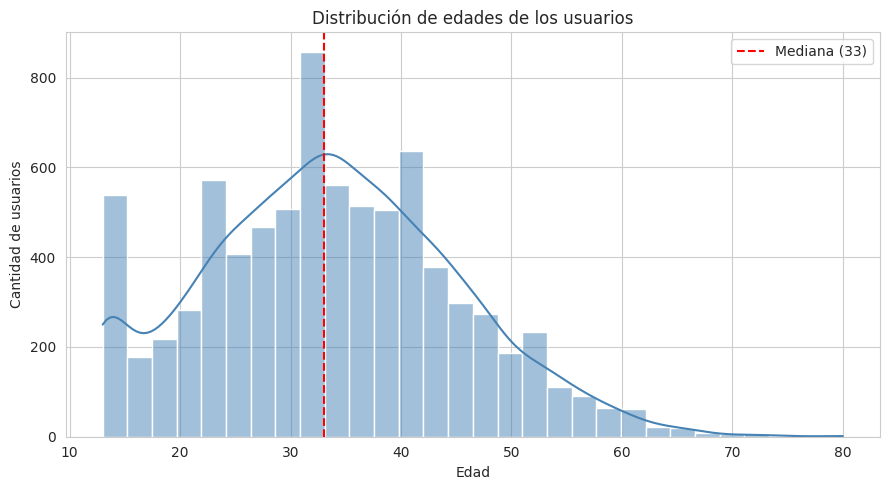

In [ ]:
plt.figure(figsize=(9,5))
sns.histplot(df['age'], bins=30, kde=True, color='steelblue', edgecolor='white')
plt.axvline(df['age'].median(), color='red', linestyle='--', label=f"Mediana ({df['age'].median():.0f})")
plt.title('Distribución de edades de los usuarios')
plt.xlabel('Edad'); plt.ylabel('Cantidad de usuarios'); plt.legend()
plt.tight_layout(); plt.show()

**Qué significa para el negocio:** la base de usuarios se concentra en adultos jóvenes (mediana ~33 años, mayoría entre 26 y 41). No es un servicio dominado por adolescentes ni por adultos mayores. Para marketing, esto sugiere orientar campañas y contenido a un público adulto-joven, que es el grueso real de clientes.

## Gráfico 2 (univariado) — Tiempo de visualización mensual

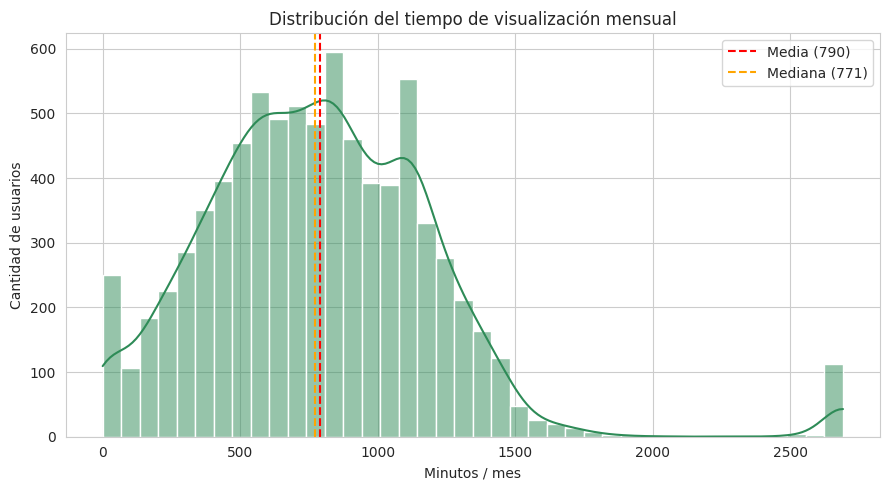

In [ ]:
plt.figure(figsize=(9,5))
sns.histplot(df['monthly_watch_time_mins'], bins=40, kde=True, color='seagreen', edgecolor='white')
plt.axvline(df['monthly_watch_time_mins'].mean(), color='red', linestyle='--',
            label=f"Media ({df['monthly_watch_time_mins'].mean():.0f})")
plt.axvline(df['monthly_watch_time_mins'].median(), color='orange', linestyle='--',
            label=f"Mediana ({df['monthly_watch_time_mins'].median():.0f})")
plt.title('Distribución del tiempo de visualización mensual')
plt.xlabel('Minutos / mes'); plt.ylabel('Cantidad de usuarios'); plt.legend()
plt.tight_layout(); plt.show()

**Qué significa para el negocio:** el consumo típico ronda los ~770 min/mes (unas 13 h), con una cola de usuarios muy intensos.

**Lectura estadística (relación media–mediana–moda):** la media (~790) es ligeramente **mayor** que la mediana (~770), es decir **Moda < Mediana < Media**. Según la teoría del análisis univariado, esto corresponde a una **distribución asimétrica positiva** (sesgada a la derecha): la cola larga está hacia los valores altos y la media es "arrastrada" por los usuarios de muy alto consumo. Por eso, para describir al usuario *típico* la **mediana es más representativa** que la media, ya que es robusta ante esos valores extremos. Ese grupo de alto consumo es, además, el más fiel y el que conviene retener.

### Medidas de dispersión y forma

Complementamos la tendencia central con medidas de **dispersión** y **forma**, siguiendo el marco
del análisis univariado. Incluimos el **coeficiente de variación (CV = desvío / media × 100)**, que al
ser *relativo y adimensional* permite comparar la variabilidad de variables con escalas distintas, y los
coeficientes de **asimetría (skewness)** y **curtosis**, que describen la forma de cada distribución.

In [ ]:
num_cols = ['age', 'monthly_watch_time_mins', 'customer_support_tickets']
resumen_forma = pd.DataFrame({
    'media': [df[c].mean() for c in num_cols],
    'desvío_std': [df[c].std() for c in num_cols],
    'CV (%)': [df[c].std()/df[c].mean()*100 for c in num_cols],
    'asimetría (skew)': [df[c].skew() for c in num_cols],
    'curtosis': [df[c].kurt() for c in num_cols],
}, index=num_cols).round(3)
resumen_forma

,media,desvío_std,CV (%),asimetría (skew),curtosis
age,33.708,11.456,33.985,0.238,-0.204
monthly_watch_time_mins,789.626,430.968,54.579,1.132,3.844
customer_support_tickets,0.803,0.894,111.342,1.136,1.338


**Interpretación de las medidas:**

**Coeficiente de variación (dispersión relativa):**
- `age` tiene el CV más bajo (~34%): es la variable **más homogénea**, los usuarios tienen edades relativamente parecidas.
- `monthly_watch_time_mins` (~55%) es más dispersa: el consumo varía mucho entre usuarios.
- `customer_support_tickets` (~111%) es la **más heterogénea** de todas: su desvío supera a su media. Tiene sentido, ya que la mayoría abre 0–1 tickets y unos pocos abren varios. El CV permite afirmar esto comparando escalas distintas, algo que el desvío solo no permitiría.

**Asimetría (skewness):**
- `age` ≈ 0.24 → **aproximadamente simétrica** (|skew| < 0.5), coherente con una base de usuarios distribuida de forma pareja en torno a los 33 años.
- `monthly_watch_time_mins` ≈ 1.13 y `customer_support_tickets` ≈ 1.14 → **asimetría positiva alta** (skew ≥ 1): ambas tienen cola hacia la derecha (media > mediana), confirmando con un número la "cola de usuarios intensos" descrita antes.

**Curtosis:**
- `monthly_watch_time_mins` ≈ 3.84 → **leptocúrtica** (curtosis > 0): pico central pronunciado y colas más pesadas que la normal, es decir, presencia de valores extremos (los super-usuarios).
- `age` ≈ −0.20 → cercana a **mesocúrtica/ligeramente platicúrtica**: forma parecida a la normal, sin colas pesadas.

**Implicancia analítica:** la asimetría positiva de `watch_time` justifica haber usado la **mediana** (no la media) para describirla e imputarla, ya que la media queda "arrastrada" por la cola de alto consumo.

## Gráfico 3 (bivariado) — Plan vs tiempo de uso

/tmp/ipykernel_584/3403776446.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='subscription_plan', y='monthly_watch_time_mins', order=orden, palette='Blues')


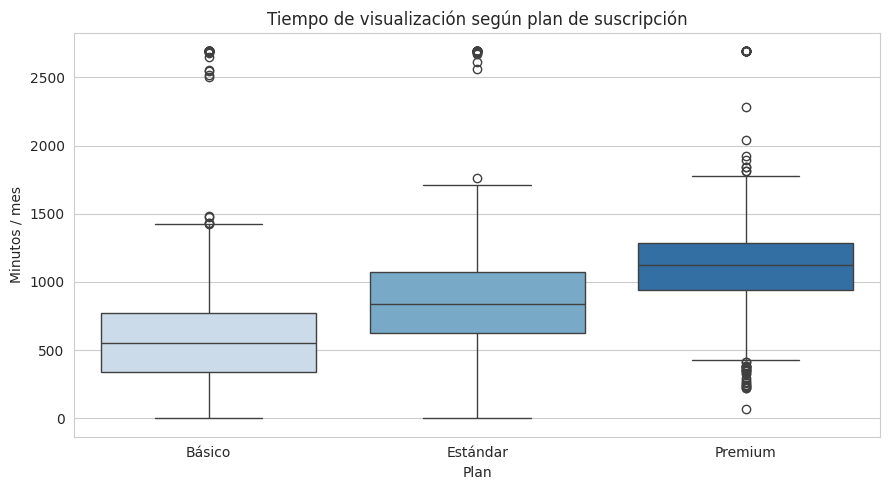

subscription_plan
Básico       587.0
Estándar     862.0
Premium     1123.0
Name: monthly_watch_time_mins, dtype: float64


In [ ]:
plt.figure(figsize=(9,5))
orden = ['Básico','Estándar','Premium']
sns.boxplot(data=df, x='subscription_plan', y='monthly_watch_time_mins', order=orden, palette='Blues')
plt.title('Tiempo de visualización según plan de suscripción')
plt.xlabel('Plan'); plt.ylabel('Minutos / mes')
plt.tight_layout(); plt.show()

print(df.groupby('subscription_plan')['monthly_watch_time_mins'].mean().round(0))

**Qué significa para el negocio:** existe una relación clara y creciente — los usuarios **Premium consumen casi el doble** que los **Básico** (≈1123 vs ≈587 min/mes), con Estándar en el medio. Quien paga más, mira más. Esto justifica el valor del plan Premium y sugiere que ofrecer upgrades a usuarios Básico de alto consumo podría aumentar ingresos: ya tienen el hábito de mirar mucho.

## Gráfico 4 (bivariado) — Plan según país

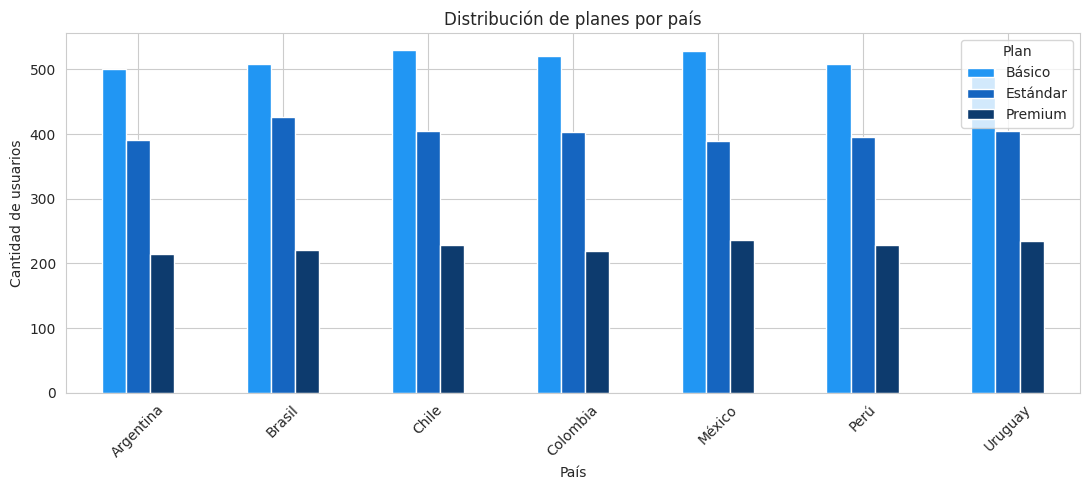

subscription_plan  Básico  Estándar  Premium
country                                     
Argentina            45.2      35.4     19.4
Brasil               43.9      36.9     19.1
Chile                45.5      34.8     19.7
Colombia             45.5      35.3     19.2
México               45.8      33.7     20.5
Perú                 44.9      34.9     20.2
Uruguay              44.1      35.4     20.5


In [ ]:
ct = pd.crosstab(df['country'], df['subscription_plan'])
ct = ct[orden]  # ordenar columnas
ct.plot(kind='bar', stacked=False, figsize=(11,5), color=['#2196F3','#1565C0','#0D3B6E'], edgecolor='white')
plt.title('Distribución de planes por país')
plt.xlabel('País'); plt.ylabel('Cantidad de usuarios')
plt.xticks(rotation=45); plt.legend(title='Plan')
plt.tight_layout(); plt.show()

# Porcentajes por país (perfil)
print((pd.crosstab(df['country'], df['subscription_plan'], normalize='index')*100).round(1)[orden])

**Qué significa para el negocio:** el reparto de planes es **muy parejo entre países** — en todos predomina Básico, sigue Estándar y Premium es minoría, en proporciones similares. No hay un mercado nacional que se comporte distinto. Implicancia: la estrategia comercial puede ser **regional unificada**; no hace falta una política de planes distinta por país, aunque sí podría trabajarse la conversión a Premium de forma transversal.

## Gráfico 5 (multivariado) — Edad, tiempo de uso y plan

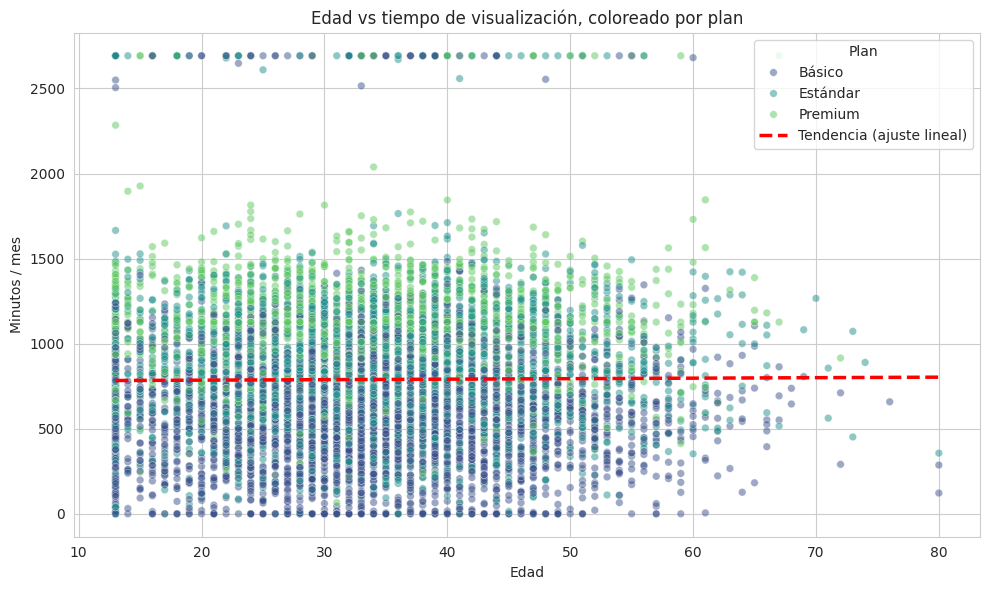

Pendiente de la tendencia: 0.293  |  correlación edad–watch_time: 0.0078


In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='age', y='monthly_watch_time_mins',
                hue='subscription_plan', hue_order=orden, palette='viridis',
                alpha=0.5, s=30)

# Línea de tendencia (np.polyfit) sobre el scatter ya existente — no es un gráfico nuevo
import numpy as np
z = np.polyfit(df['age'], df['monthly_watch_time_mins'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['age'].min(), df['age'].max(), 100)
plt.plot(x_line, p(x_line), 'r--', linewidth=2.5, label='Tendencia (ajuste lineal)')

plt.title('Edad vs tiempo de visualización, coloreado por plan')
plt.xlabel('Edad'); plt.ylabel('Minutos / mes')
plt.legend(title='Plan')
plt.tight_layout(); plt.show()

print(f'Pendiente de la tendencia: {z[0]:.3f}  |  correlación edad–watch_time: {df["age"].corr(df["monthly_watch_time_mins"]):.4f}')

**Qué significa para el negocio:** el gráfico cruza tres variables a la vez. Dos lecturas:
- **La edad no influye en el consumo:** la nube no sube ni baja con la edad — jóvenes y mayores miran cantidades parecidas. La edad no sirve para predecir cuánto va a mirar alguien.
- **El plan sí separa los niveles de consumo:** los puntos de Premium se ubican sistemáticamente más arriba (más minutos) que los de Básico, sin importar la edad.

**Conclusión de negocio:** para predecir o segmentar por consumo, **el plan es la variable que importa, no la edad**. Las campañas de retención e incentivo deberían segmentarse por plan/comportamiento de uso, no por grupo etario.

### Tabla dinámica (pivot table) — síntesis numérica

Como complemento a los gráficos (sin sumar visualizaciones), una **tabla dinámica** resume el
consumo promedio cruzando dos variables categóricas: plan y país. Es la versión numérica del
análisis bivariado, útil para lectura precisa.

In [ ]:
pivot = pd.pivot_table(df,
                       values='monthly_watch_time_mins',
                       index='country',
                       columns='subscription_plan',
                       aggfunc='mean').round(0)[orden]
pivot

subscription_plan,Básico,Estándar,Premium
country,,,
Argentina,596.0,869.0,1143.0
Brasil,596.0,856.0,1132.0
Chile,567.0,842.0,1148.0
Colombia,587.0,862.0,1085.0
México,584.0,866.0,1103.0
Perú,594.0,880.0,1128.0
Uruguay,583.0,858.0,1121.0


**Interpretación:** la tabla confirma numéricamente lo que mostró el gráfico 3: dentro de **cada país**, el consumo promedio crece de Básico a Premium. El patrón es **consistente en todos los países** (no hay un país donde Básico supere a Premium), lo que refuerza que la relación plan → consumo es estructural y no un efecto de algún mercado puntual.